__Задача 1__: Разработка интеллектуальной системы классификации объектов по радиолокационным изображениям

Используется  набор данных MSTAR, содержащий 8688 фрагментов радилокационных изображений синтезированной апертуры (SAR) от 7 наземных транспортных средств. Данные были собраны с помощью датчика X-диапазона с разрешением 1 фут (0,3 м) с разными углами наклона.

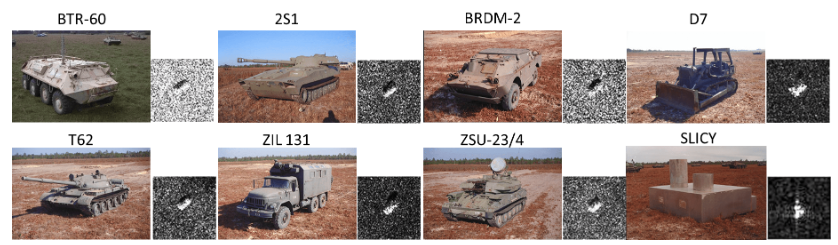

__Задача__:
- спроектировать архитектуру нейронной сети для классификации объектов;
- обучить нейронную сеть;
- оценить точность классификации;
- оценить зависимость точности классификации от объёма обучающих данных.  

In [1]:
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
from tqdm.auto import tqdm

## загружаем данные

In [2]:
folder_img = '../data/MSTAR_TargetData' # папка с исходными данными 

In [3]:
# формируем список файлов с картинками
!find ../data/MSTAR_TargetData/ -name *.JPG > ../data/MSTAR_TargetData/list.txt

In [4]:
# загрудаем список файлов с картинками
with open( folder_img+'/list.txt','rt') as f: files = f.read().split()
display( len(files) )

8688

In [5]:
# метки картинок
labels = [ f.split('/')[-2] for f in files ]
set(labels)

{'2S1', 'BRDM_2', 'BTR_60', 'D7', 'SLICY', 'T62', 'ZIL131', 'ZSU_23_4'}

<Axes: ylabel='label'>

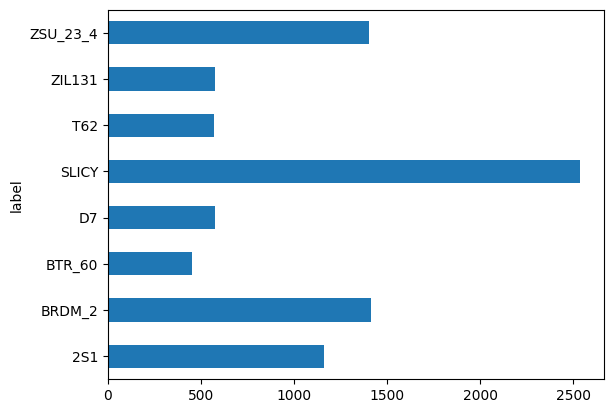

In [6]:
# количество картинок по классам
import pandas as pd 
pd.DataFrame(labels,columns=['label']).groupby('label').size().plot.barh()

In [7]:
images = [ np.array(Image.open(f)) for f in tqdm(files) ]

  0%|          | 0/8688 [00:00<?, ?it/s]

In [8]:
set([ m.shape for m in images ])

{(54, 54),
 (128, 128),
 (129, 128),
 (158, 158),
 (173, 172),
 (178, 177),
 (193, 192)}

<Axes: ylabel='label'>

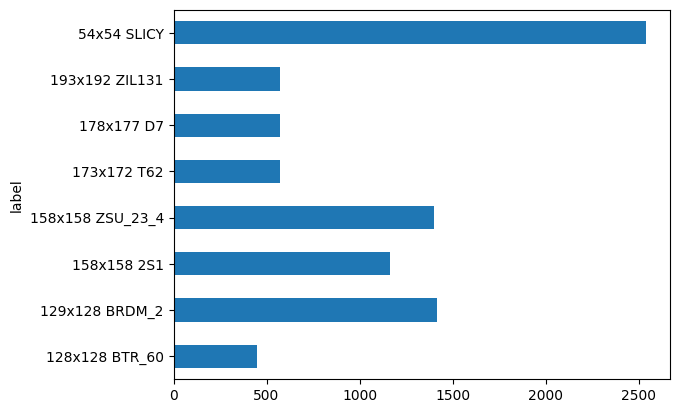

In [9]:
pd.DataFrame([ 
        '%dx%d %s'%(m.shape[0],m.shape[1],l) for m,l in zip(images,labels) 
    ],columns=['label']).groupby('label').size().plot.barh()

---

## формируем датасет

In [10]:
# дополняем картинки до единого размера
def img_pad_zeros(im, max_size = (193, 192) ):
    im_size = im.shape
    pad_width = (np.array(max_size) - np.array(im_size))//2+1
    return np.pad(array=im, pad_width=pad_width, mode='constant' )[:max_size[0],:max_size[1]]

data = np.vstack([
        img_pad_zeros(im)[np.newaxis,np.newaxis,:,:]
        for im in images 
    ])

display( data.shape )

In [13]:
# номера классов
classes = { t:i for i,t in enumerate(sorted(set(labels))) } 
target = [ classes[l] for l in labels ] # вектор меток

n_classes = len(classes) # количество классов
display(n_classes)

8

In [14]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=.1 
)

display( data_train.shape, data_test.shape )

(7819, 1, 193, 192)

(869, 1, 193, 192)

In [15]:
import torch

# from torch.utils.data import  Dataset
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# import torchvision
# from torchvision.io import read_image
# from torchvision.transforms import Normalize
# from torchvision.transforms import Resize

In [17]:
ds_train = TensorDataset( 
        torch.Tensor( (data_train/255.).astype(np.float32) ),
        torch.Tensor( np.eye(n_classes)[target_train].astype(np.float32) )
    )

display( len(ds_train) )

7819

## строим модель

In [18]:
import torch.nn as nn
import torch.nn.functional as F

In [19]:
from collections import OrderedDict

model = nn.Sequential(OrderedDict([
          ('conv1',  nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3)),
          ('bn1',  nn.BatchNorm2d(32) ),
          ('relu1',  nn.ReLU()),
          # ('mpool1', nn.MaxPool2d(kernel_size=4) ),
          ('conv2',  nn.Conv2d(in_channels=32,out_channels=32,kernel_size=3)),
          ('bn2',  nn.BatchNorm2d(32) ),
          ('relu2',  nn.ReLU()),
          ('mpool2', nn.MaxPool2d(kernel_size=2) ),
          ('conv3',  nn.Conv2d(in_channels=32,out_channels=64,kernel_size=6)),
          ('relu3',  nn.ReLU()),
          ('flat',   nn.Flatten(start_dim=1) ),
          ('lin1',   nn.Linear(in_features=506944,out_features=128) ),
          ('relu4',  nn.ReLU()),
          ('lin2',   nn.Linear(in_features=128,out_features=n_classes) ),
          ('smax',   nn.Softmax(dim=-1) ),
        ]))

model

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (mpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(6, 6), stride=(1, 1))
  (relu3): ReLU()
  (flat): Flatten(start_dim=1, end_dim=-1)
  (lin1): Linear(in_features=506944, out_features=128, bias=True)
  (relu4): ReLU()
  (lin2): Linear(in_features=128, out_features=8, bias=True)
  (smax): Softmax(dim=-1)
)

In [20]:
# проверка модели
device = 'cpu'
with torch.no_grad():
    for x,target in DataLoader(ds_train, batch_size=7, shuffle=False):
        out = model(x.to(device)).cpu().detach().numpy()
        break

display(out.shape)

(7, 8)

### обучаем модель

In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=9e-5) 

# optimizer = optim.Adam(model.parameters(), lr=1e-4) 
# from torch.optim.lr_scheduler import ExponentialLR
# scheduler = ExponentialLR(optimizer, gamma=0.91)

In [23]:
# проверяем наличие GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
display(device)

model = model.to(device) # перемещаем модель на GPU (если есть)

device(type='cuda', index=0)

In [25]:
# from torch.utils.data import DataLoader
# for x,target in DataLoader(data_train, batch_size=3, shuffle=True):
#     display(x.shape)
#     display(target.shape)
#     break

In [26]:
%%time

from tqdm.auto import tqdm

n_epoch = 7
history_loss = []
batch_size = 64

for epoch in tqdm(range(n_epoch)): 
    epoch_loss = []
    for x,target in DataLoader(ds_train, batch_size=batch_size, shuffle=True):
        optimizer.zero_grad() # zero the parameter gradients
        loss = criterion( model(x.to(device)), target.to(device) )  # forward 
        loss.backward() 
        optimizer.step()
        epoch_loss.append( loss.item() )
    history_loss.append( np.array(epoch_loss).mean() )
#     scheduler.step()

  0%|          | 0/7 [00:00<?, ?it/s]

CPU times: user 4min 31s, sys: 477 ms, total: 4min 32s
Wall time: 3min 52s


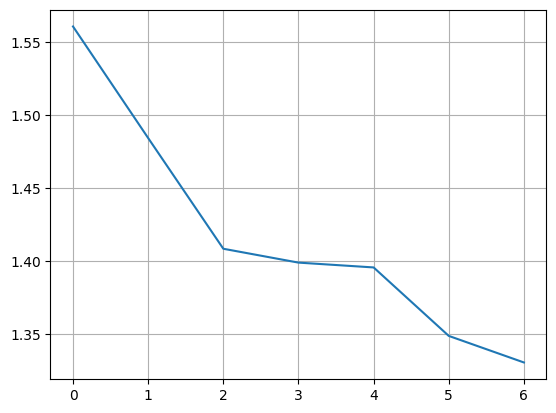

In [27]:
plt.plot(history_loss)
plt.grid()

In [28]:
# scheduler.get_last_lr()

## тестируем

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [29]:
target_names = classes.keys() # названия классов

### учебный датасет

In [30]:
images,label,score = [],[],[]

with torch.no_grad(): # отключаем режим обучение модели
    for x,target in DataLoader(ds_train, batch_size=batch_size, shuffle=False):
        images.append(x.numpy() ) 
        label.append( np.argmax(target.numpy(),axis=1) )
        score.append( model(x.to(device)).cpu().detach().numpy() )

target = np.hstack(label)
predicted = np.argmax(np.vstack(score),axis=1)
print(  classification_report( target,predicted, target_names=target_names, ) )

              precision    recall  f1-score   support

         2S1       1.00      1.00      1.00      1036
      BRDM_2       0.75      1.00      0.86      1282
      BTR_60       0.00      0.00      0.00       420
          D7       1.00      1.00      1.00       518
       SLICY       1.00      1.00      1.00      2263
         T62       1.00      1.00      1.00       513
      ZIL131       1.00      1.00      1.00       512
    ZSU_23_4       1.00      1.00      1.00      1275

    accuracy                           0.95      7819
   macro avg       0.84      0.87      0.86      7819
weighted avg       0.90      0.95      0.92      7819



/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


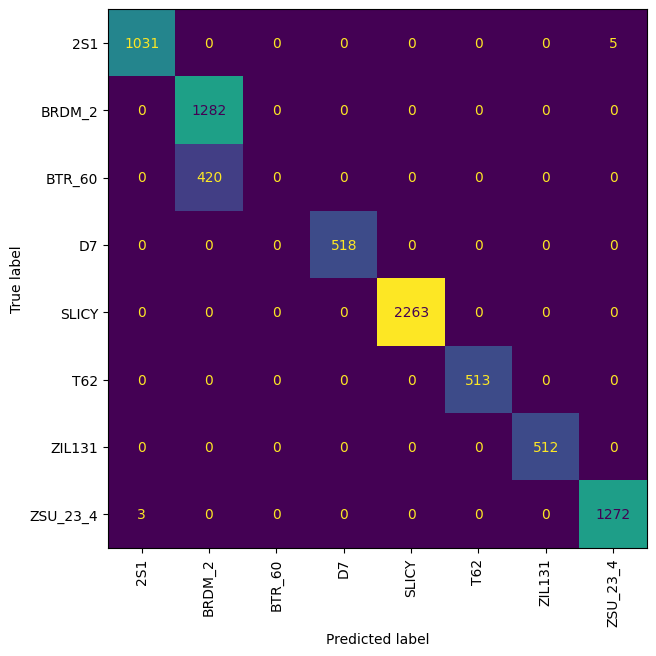

In [31]:
fig,ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(target,predicted), 
        display_labels=target_names,
    )
disp.plot(ax=ax, xticks_rotation='vertical', include_values=True, cmap='viridis',  colorbar=False,)
plt.show()

### тестовый датасет

In [32]:
ds_test = TensorDataset( 
        torch.Tensor( (data_test/255.).astype(np.float32) ),
        torch.Tensor( np.eye(n_classes)[target_test].astype(np.float32) )
    )

display( len(ds_test) )

869

In [33]:
images,label,score = [],[],[]

with torch.no_grad():
    for x,target in DataLoader(ds_test, batch_size=batch_size, shuffle=False):
        images.append(x.numpy() ) 
        label.append( np.argmax(target.numpy(),axis=1) )
        score.append( model(x.to(device)).cpu().detach().numpy() )

target = np.hstack(label)
predicted = np.argmax(np.vstack(score),axis=1)
print(  classification_report( target,predicted, target_names=target_names, ) )

              precision    recall  f1-score   support

         2S1       0.99      0.97      0.98       128
      BRDM_2       0.81      1.00      0.90       133
      BTR_60       0.00      0.00      0.00        31
          D7       1.00      1.00      1.00        55
       SLICY       1.00      1.00      1.00       276
         T62       1.00      1.00      1.00        59
      ZIL131       1.00      1.00      1.00        61
    ZSU_23_4       0.97      0.99      0.98       126

    accuracy                           0.96       869
   macro avg       0.85      0.87      0.86       869
weighted avg       0.93      0.96      0.94       869



/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/venv/jupyter_3.9_1/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


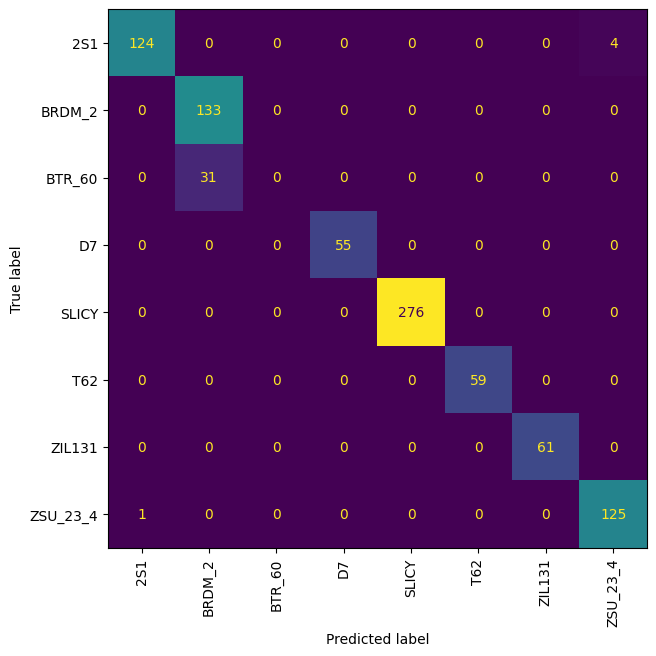

In [34]:
fig,ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(target,predicted), 
        display_labels=target_names,
    )
disp.plot(ax=ax, xticks_rotation='vertical', include_values=True, cmap='viridis',  colorbar=False,)
plt.show()

---

In [36]:
# !pip3 install watermark
# Python package versions used
%load_ext watermark
%watermark --python
%watermark --iversions
#

Python implementation: CPython
Python version       : 3.9.16
IPython version      : 8.13.2

matplotlib : 3.7.1
PIL        : 9.5.0
torchvision: 0.15.2
torch      : 2.0.1
numpy      : 1.23.5
pandas     : 2.0.1

